In [1]:
import numpy as np
import pandas as pd
import os
import time
from tqdm import tqdm, trange
import sys
import matplotlib.pyplot as plt
import pickle
import random
import math

# variaveis
L = 100 # lado do lattice
n_lagartos = L**2 # lagartos que cabem no lattice
estrategias = ['O', 'Y', 'B'] # estratégias possíveis
index_map = {'O': 0, 'Y': 1, 'B': 2}
n_geracoes = 200
n_pop = 1 # número de populações independentes
prob_mutacao = None # probabilidade de mutação a cada geração
LN = int(input("Vizinhança de aprendizado: "))
custo = float(input("Custo: "))

output_dir = f"C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/vizinhanca_aprendizado-interacao/teste/LN_{str(LN)}/custo_{str(custo)}/"
os.makedirs(output_dir, exist_ok=True)

In [2]:
class Lagarto:
  def __init__(self, i, j, estrategia, fitness, coord_vizinhos_interacao, estrategia_vizinhos_interacao, coord_vizinhos_aprendizado, estrategia_vizinhos_aprendizado, t, n_vizinhos_interacao, n_vizinhos_aprendizado):
    self.i = i # linha
    self.j = j # coluna
    self.estrategia = estrategia
    self.fitness = 0 # inicia com 0 de fitness
    self.coord_vizinhos_interacao = [] # lista vazia para adicionar as coordenadas dos vizinhos
    self.estrategia_vizinhos_interacao = [] # lista vazia para adicionar as estratégias dos vizinhos
    self.coord_vizinhos_aprendizado = []
    self.estrategia_vizinhos_aprendizado = []
    self.t = t  # determina a geracao do lagarto
    self.n_vizinhos_interacao = n_vizinhos_interacao # número de vizinhos que o lagarto efetivamente joga
    self.n_vizinhos_aprendizado = n_vizinhos_aprendizado # número de vizinhos que o lagarto olha para aprender

  def calcular_coord_vizinhos(self, L, tipo):
    if tipo == 'interacao':
        # Calcula o menor raio necessário para abranger pelo menos n_vizinhos
        n_vizinhos = self.n_vizinhos_interacao
        raio = math.ceil((math.sqrt(n_vizinhos + 1) - 1) / 2)
        vizinhos = []
        for dx in range(-raio, raio + 1):
            for dy in range(-raio, raio + 1):
                if dx == 0 and dy == 0: # Moore
                    continue
                ni = (self.i + dx) % L
                nj = (self.j + dy) % L
                vizinhos.append((ni, nj))
        vizinhos = list(set(vizinhos))
        if len(vizinhos) < n_vizinhos:
            raise ValueError(f"Não há vizinhos suficientes: pedido={n_vizinhos}, disponíveis={len(vizinhos)}")
        selecionados = random.sample(vizinhos, n_vizinhos)
        self.coord_vizinhos_interacao = selecionados

    elif tipo == 'aprendizado':
        n_vizinhos = self.n_vizinhos_aprendizado
        raio = math.ceil((math.sqrt(n_vizinhos + 1) - 1) / 2)
        vizinhos = []
        for dx in range(-raio, raio + 1):
            for dy in range(-raio, raio + 1):
                if dx == 0 and dy == 0:
                    continue
                ni = (self.i + dx) % L
                nj = (self.j + dy) % L
                vizinhos.append((ni, nj))
        vizinhos = list(set(vizinhos))
        if len(vizinhos) < n_vizinhos:
            raise ValueError(f"Não há vizinhos suficientes: pedido={n_vizinhos}, disponíveis={len(vizinhos)}")
        selecionados = random.sample(vizinhos, n_vizinhos)
        self.coord_vizinhos_aprendizado = selecionados
    
  def obter_estrategia_vizinhos(self, matriz_posicao):
      self.estrategia_vizinhos_interacao = [matriz_posicao[ni, nj] for ni, nj in self.coord_vizinhos_interacao] # dadas as coordenadas, obtém a estratégia do lagarto que ocupa aquela posição
      self.estrategia_vizinhos_aprendizado = [matriz_posicao[ni, nj] for ni, nj in self.coord_vizinhos_aprendizado] # dadas as coordenadas, obtém a estratégia do lagarto que ocupa aquela posição

  def mutacao(self, prob_mutacao): # função de mutação
    if np.random.rand() < prob_mutacao: # sorteia um valor entre 0 e 1, se for menor que a probabilidade de mutação, o lagarto muda de estratégia
        estrategias_possiveis = [e for e in estrategias if e != self.estrategia] # obtém as estratégias possíveis, exceto a atual
        self.estrategia = np.random.choice(estrategias_possiveis) # escolhe uma nova estratégia aleatoriamente para mutar

  def adicionar_vizinhos_inicial(self, LN):
      if self.estrategia == 'Y':
          #n_vizinhos_interacao = np.random.randint(1, 9)
          n_vizinhos_interacao = 24
          self.n_vizinhos_interacao = n_vizinhos_interacao
          #n_vizinhos_aprendizado = np.random.randint(1, 9)
          n_vizinhos_aprendizado = LN
          self.n_vizinhos_aprendizado = n_vizinhos_aprendizado
      elif self.estrategia == 'O':
          #n_vizinhos_interacao = np.random.randint(1, 9)
          n_vizinhos_interacao = 24
          self.n_vizinhos_interacao = n_vizinhos_interacao
          #n_vizinhos_aprendizado = np.random.randint(1, 9)
          n_vizinhos_aprendizado = LN
          self.n_vizinhos_aprendizado = n_vizinhos_aprendizado
      elif self.estrategia == 'B':
          #n_vizinhos_interacao = np.random.randint(1, 9)
          n_vizinhos_interacao = 24
          self.n_vizinhos_interacao = n_vizinhos_interacao
          #n_vizinhos_aprendizado = np.random.randint(1, 9)
          n_vizinhos_aprendizado = LN
          self.n_vizinhos_aprendizado = n_vizinhos_aprendizado

def calcular_media_vizinhos(lagartos, estrategias, tipo):
    if tipo == 'interacao':
        medias_interacao = []
        for e in estrategias:
            #viz = [lag.n_vizinhos_realizado for lag in lagartos if lag.estrategia == e]
            viz = [lag.n_vizinhos_interacao for lag in lagartos if lag.estrategia == e]
            medias_interacao.append(np.mean(viz) if len(viz) > 0 else 0)
        return medias_interacao # retorna a média de vizinhos para cada estratégia

    elif tipo == 'aprendizado':
        medias_aprendizado = []
        for e in estrategias:
            viz = [lag.n_vizinhos_aprendizado for lag in lagartos if lag.estrategia == e]
            medias_aprendizado.append(np.mean(viz) if len(viz) > 0 else 0)
        return medias_aprendizado # retorna a média de vizinhos para cada estratégia

In [22]:
def criar_lagartos(n_lagartos, L, estrategias): # define as posições e estratégias dos lagartos no t = 0
  lista_lagartos = []

  # posições iniciais aleatórias
  all_positions = [(i, j) for i in range(L) for j in range(L)] # forma todas as posições possíveis em um lattice
  unique_positions_indices = np.random.choice(len(all_positions), n_lagartos, replace=False) # determina o índice de onde vai ficar cada posição
  unique_positions = [all_positions[i] for i in unique_positions_indices] # basicamente, ele embaralhou as posições

  for g in range(n_lagartos):
    i, j = unique_positions[g] # posição na matriz
    estrategia = np.random.choice(estrategias) # sorteia a estrategia
    lista_lagartos.append(Lagarto(i, j, estrategia, 0, [], [], [], [], 0, 0, 0)) # cria o lagarto
  return lista_lagartos

#def calcular_fitness(lagarto, index_map, matriz_posicao, custo): # função para calcular o fitness do lagarto
    #fitness_total = 0 # inicia no 0

    #matriz_payoff = np.array([[1, 0.5, 2],
    #                          [1+custo, 1, 1-custo],
    #                          [0.5, 2, 1]])
    
    #vizinhos_interacao = set(lagarto.coord_vizinhos_interacao)
    #for ni, nj in vizinhos_interacao:
    #    vizinho_estrat = matriz_posicao[ni, nj] # pega a estratégia do vizinho dadas as suas coordenadas
    #    if vizinho_estrat is not None:
    #        fitness_total += matriz_payoff[index_map[lagarto.estrategia], index_map[vizinho_estrat]] # calcula o payoff do lagarto contra o vizinho de acordo com a matriz de payoff e soma ao fitness total
    #lagarto.fitness = fitness_total # adiciona ruído gaussiano ao fitness
    #return fitness_total

def calcular_fitness(lagarto, index_map, matriz_posicao, custo): # função para calcular o fitness do lagarto
    fitness_total = 0 # inicia no 0

    matriz_payoff = np.array([[1, 0.5, 2],
                              [1+custo, 1, 1-custo],
                              [0.5, 2, 1]])
    
    for vizinhos in lagarto.estrategia_vizinhos_aprendizado:
        if vizinhos is not None:
            fitness_total += matriz_payoff[index_map[lagarto.estrategia], index_map[vizinhos]] # calcula o payoff do lagarto contra o vizinho de acordo com a matriz de payoff e soma ao fitness total
    lagarto.fitness = fitness_total # adiciona ruído gaussiano ao fitness
    return fitness_total

calcular_freq = lambda mat: np.array([np.sum(mat == s) / (L ** 2) for s in ['O', 'Y', 'B']]) # calcula a frequência de cada estratégia no lattice na ordem O, Y, B

In [4]:
def atualizar_lagartos(lagartos): # função que atualiza as estratégias dos lagartos com base no fitness dos vizinhos
    novas_estrategias = {} # Dicionário para armazenar as novas estratégias
    mapa = {(l.i, l.j): l for l in lagartos} # dicionário para acessar lagartos pela posição

    for lagarto in lagartos:
        melhor_estrategia = lagarto.estrategia # inicia com a própria estratégia
        maior_fitness = lagarto.fitness # verifica o fitness do próprio lagarto
        
        # verifica o fitness dos vizinhos
        for (ni, nj) in lagarto.coord_vizinhos_aprendizado:
            vizinho = mapa[(ni, nj)] # usa o dicionário para achar o vizinho
            if vizinho.fitness > maior_fitness: # se o fitness do vizinho for maior que o maior fitness atual
                maior_fitness = vizinho.fitness # atualiza o maior fitness
                melhor_estrategia = vizinho.estrategia # atualiza a melhor estratégia
                
            if vizinho.fitness == maior_fitness:
                a = np.random.rand()
                if a < 0.5:
                    maior_fitness = vizinho.fitness # atualiza o maior fitness
                    melhor_estrategia = vizinho.estrategia # atualiza a melhor estratégia
                    
                else:
                    pass
                # se houver empate de fitness ou for menor, mantém a estratégia atual (não muda)

        novas_estrategias[(lagarto.i, lagarto.j)] = melhor_estrategia # armazena a nova estratégia no dicionário
        
     # atualiza as estratégias de todos os lagartos simultaneamente
    for lagarto in lagartos:
        lagarto.estrategia = novas_estrategias[(lagarto.i, lagarto.j)]  # atualiza estratégia
        # Garantir tamanhos fixos para O e B; somente Y herda vizinhança adaptativa
        #if lagarto.estrategia == 'O':
            #lagarto.n_vizinhos = 24
        #elif lagarto.estrategia == 'B':
            #lagarto.n_vizinhos = 8
        #else:  # 'Y'
        
    return lagartos

In [7]:
# iniciando a simulação
def simulacao(custo, LN, prob_mutacao = None, seed = None):
    
    resultados = []

    for pop in range(n_pop): # loop para cada população independente
        if seed is not None:
          np.random.seed(seed + pop) # coloca uma semente diferente pra cada pop, garantindo independência e reproducibilidade

        matriz_posicao = np.full((L, L), None) # cria uma matriz vazia com None

        lista_lagartos = criar_lagartos(n_lagartos, L, estrategias) # cria os lagartos
        for lagarto in lista_lagartos:
            lagarto.adicionar_vizinhos_inicial(LN) # adiciona o número de vizinhos iniciais de acordo com a estratégia
            matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia) # cria a matriz de posições de acordo com os lagartos

        freq = calcular_freq(matriz_posicao) # calcula a frequência inicial
        
        resultados.append({
           "pop": pop,
           "t": 0,
           "freq_O": freq[0],
           "freq_Y": freq[1],
           "freq_B": freq[2],
           "custo": custo,
           "IN": 24,
           "LN": LN
        })

        for t in range(1, n_geracoes + 1): # loop para cada geração dentro da população
          print(f"População {pop} - Geração {t}/{n_geracoes}")
          # determinando os vizinhos
          for lagarto in lista_lagartos:
            lagarto.calcular_coord_vizinhos(L, 'interacao') # calcula as coordenadas dos vizinhos
            lagarto.calcular_coord_vizinhos(L, 'aprendizado') # calcula as coordenadas dos vizinhos
            lagarto.obter_estrategia_vizinhos(matriz_posicao) # obtém as estratégias dos vizinhos

          # calculando o fitness
          for lagarto in lista_lagartos:
            calcular_fitness(lagarto, index_map, matriz_posicao, custo = custo) # calcula o fitness do lagarto de acordo com seus vizinhos e a matriz de fitness

          lista_lagartos = atualizar_lagartos(lista_lagartos) # atualiza as estratégias dos lagartos de acordo com o maior fitness dos vizinhos

          if prob_mutacao is not None:
            for lagarto in lista_lagartos:
              lagarto.mutacao(prob_mutacao) # aplica a mutação

          # atualiza a matriz de posição com as novas estratégias e com as mutações
          matriz_posicao = np.full((L, L), None)
          for lagarto in lista_lagartos:
            matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia)
          #print(matriz_posicao)

          for lagarto in lista_lagartos:
              lagarto.t += 1 # incrementa a geração do lagarto

          freq = calcular_freq(matriz_posicao)
          
          resultados.append({
           "pop": pop,
           "t": t,
           "freq_O": freq[0],
           "freq_Y": freq[1],
           "freq_B": freq[2],
           "custo": custo,
           "IN": 24,
           "LN": LN
        })
          
    return resultados

resultados = simulacao(custo = custo, LN = LN, prob_mutacao = prob_mutacao, seed = 8)

População 0 - Geração 1/200
População 0 - Geração 2/200
População 0 - Geração 3/200
População 0 - Geração 4/200
População 0 - Geração 5/200
População 0 - Geração 6/200
População 0 - Geração 7/200
População 0 - Geração 8/200
População 0 - Geração 9/200
População 0 - Geração 10/200
População 0 - Geração 11/200
População 0 - Geração 12/200
População 0 - Geração 13/200
População 0 - Geração 14/200
População 0 - Geração 15/200
População 0 - Geração 16/200
População 0 - Geração 17/200
População 0 - Geração 18/200
População 0 - Geração 19/200
População 0 - Geração 20/200
População 0 - Geração 21/200
População 0 - Geração 22/200
População 0 - Geração 23/200
População 0 - Geração 24/200
População 0 - Geração 25/200
População 0 - Geração 26/200
População 0 - Geração 27/200
População 0 - Geração 28/200
População 0 - Geração 29/200
População 0 - Geração 30/200
População 0 - Geração 31/200
População 0 - Geração 32/200
População 0 - Geração 33/200
População 0 - Geração 34/200
População 0 - Geração 3

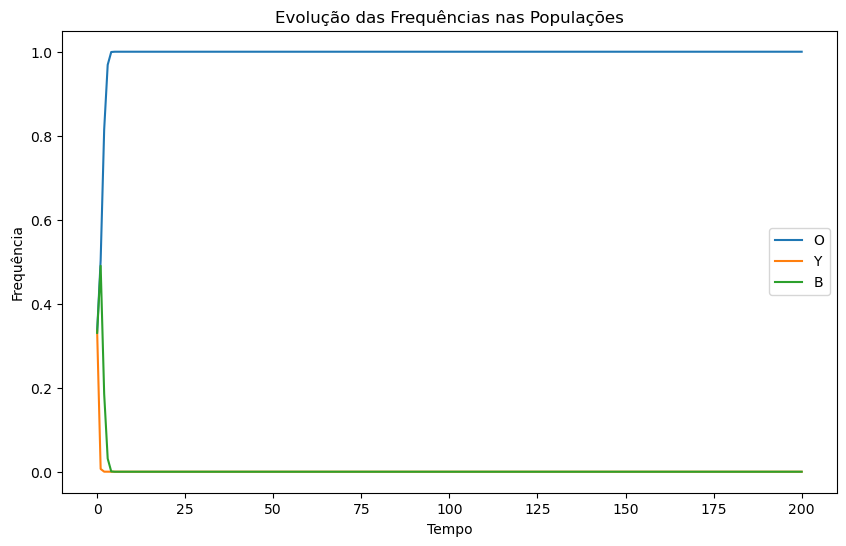

In [8]:
resultados_df = pd.DataFrame(resultados)

plt.figure(figsize=(10, 6))
plt.plot(resultados_df['t'], resultados_df['freq_O'], label='O')
plt.plot(resultados_df['t'], resultados_df['freq_Y'], label='Y')
plt.plot(resultados_df['t'], resultados_df['freq_B'], label='B')
plt.xlabel('Tempo')
plt.ylabel('Frequência')
plt.title('Evolução das Frequências nas Populações')
plt.legend()
plt.show()

In [23]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt


def simulacao_gif(custo, LN, prob_mutacao = None, seed = None):
    
    matrizes_posicao_hist = [] # lista para armazenar as matrizes de posição de cada geração
    matrizes_fitness_hist = []

    matriz_posicao = np.full((L, L), None) # cria uma matriz vazia com None
    matriz_fitness = np.full((L, L), 0.0) # cria uma matriz vazia com 0

    if seed is not None:
        np.random.seed(seed) # coloca uma semente diferente pra cada pop, garantindo independência e reproducibilidade
   
    lista_lagartos = criar_lagartos(n_lagartos, L, estrategias) # cria os lagartos
    
    for lagarto in lista_lagartos:
        lagarto.adicionar_vizinhos_inicial(LN) # adiciona o número de vizinhos iniciais de acordo com a estratégia
        matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia) # cria a matriz de posições de acordo com os lagartos

    matrizes_posicao_hist.append(matriz_posicao.copy()) # junta as matrizes em uma lista
    matrizes_fitness_hist.append(matriz_fitness.copy())

    for t in range(1, n_geracoes + 1): # loop para cada geração dentro da população
      print(f"Geração {t}/{n_geracoes}")
      for lagarto in lista_lagartos:
        lagarto.calcular_coord_vizinhos(L, 'interacao') # calcula as coordenadas dos vizinhos
        lagarto.calcular_coord_vizinhos(L, 'aprendizado') # calcula as coordenadas dos vizinhos
        lagarto.obter_estrategia_vizinhos(matriz_posicao) # obtém as estratégias dos vizinhos

      # calculando o fitness
      for lagarto in lista_lagartos:
        calcular_fitness(lagarto, index_map, matriz_posicao, custo = custo) # calcula o fitness do lagarto de acordo com seus vizinhos e a matriz de fitness

      matriz_fitness = np.full((L, L), 0.0)
      for lagarto in lista_lagartos:
        matriz_fitness[lagarto.i, lagarto.j] = float(lagarto.fitness)

      lista_lagartos = atualizar_lagartos(lista_lagartos) # atualiza as estratégias dos lagartos de acordo com o maior fitness dos vizinhos

      if prob_mutacao is not None:
        for lagarto in lista_lagartos:
          lagarto.mutacao(prob_mutacao) # aplica a mutação

      # atualiza a matriz de posição com as novas estratégias e com as mutações
      matriz_posicao = np.full((L, L), None)
      for lagarto in lista_lagartos:
        matriz_posicao[lagarto.i, lagarto.j] = str(lagarto.estrategia)
      #print(matriz_posicao)

      for lagarto in lista_lagartos:
          lagarto.t += 1 # incrementa a geração do lagarto

      matrizes_posicao_hist.append(matriz_posicao.copy()) # Append updated matrix position
      matrizes_fitness_hist.append(matriz_fitness.copy())
          
    return matrizes_posicao_hist, matrizes_fitness_hist

matrizes_posicao_hist, matrizes_fitness_hist = simulacao_gif(custo = custo, LN = LN, prob_mutacao = prob_mutacao, seed = 9)

Geração 1/200
Geração 2/200
Geração 3/200
Geração 4/200
Geração 5/200
Geração 6/200
Geração 7/200
Geração 8/200
Geração 9/200
Geração 10/200
Geração 11/200
Geração 12/200
Geração 13/200
Geração 14/200
Geração 15/200
Geração 16/200
Geração 17/200
Geração 18/200
Geração 19/200
Geração 20/200
Geração 21/200
Geração 22/200
Geração 23/200
Geração 24/200
Geração 25/200
Geração 26/200
Geração 27/200
Geração 28/200
Geração 29/200
Geração 30/200
Geração 31/200
Geração 32/200
Geração 33/200
Geração 34/200
Geração 35/200
Geração 36/200
Geração 37/200
Geração 38/200
Geração 39/200
Geração 40/200
Geração 41/200
Geração 42/200
Geração 43/200
Geração 44/200
Geração 45/200
Geração 46/200
Geração 47/200
Geração 48/200
Geração 49/200
Geração 50/200
Geração 51/200
Geração 52/200
Geração 53/200
Geração 54/200
Geração 55/200
Geração 56/200
Geração 57/200
Geração 58/200
Geração 59/200
Geração 60/200
Geração 61/200
Geração 62/200
Geração 63/200
Geração 64/200
Geração 65/200
Geração 66/200
Geração 67/200
Gera

In [21]:
# gerando o GIF das posições

import matplotlib.colors as mcolors

cores_grid = {"O": "#FD9800", "B": "#0047B3", "Y": "#FFF237"}

def matriz_para_rgb(matriz):
    # Converte hex para RGB normalizado (0-1)
    return np.array([[mcolors.to_rgb(cores_grid.get(cell, "#FFFFFF")) for cell in row] for row in matriz])

# Crie a figura
fig, ax = plt.subplots(figsize=(6, 6))

def update(frame):
    ax.clear()
    ax.imshow(matriz_para_rgb(matrizes_posicao_hist[frame]))
    ax.set_title(f"Geração {frame}")
    ax.axis('off')

ani = animation.FuncAnimation(
    fig, update, frames=len(matrizes_posicao_hist), interval=100, repeat=False
)


# Salvar como GIF
ani.save(os.path.join(output_dir, f"simulacao_grid.gif"), writer='pillow', fps=5)
ani.save(os.path.join(output_dir, f"simulacao_grid.mp4"), writer='ffmpeg', fps=5)
plt.close()